#**class_08_regression_metrics_case**

##**Agenda**

- **PART 1 — Why Evaluation Metrics Matter**
- **PART 2 — Mean Absolute Error (MAE)**
- **PART 3 — Root Mean Squared Error (RMSE)**
- **PART 4 — R² Score**
- **PART 5 — Adjusted R²**
- **PART 6 — Metric Comparison**
- **PART 7 — Overfitting & Bias–Variance Tradeoff**
- **PART 8 — Regression Case Study**


#**PART 1 — Why Evaluation Metrics Matter**

**Why Model Evaluation Exists**

- Suppose we build a model that predicts house prices.

**Actual Price:**

- ₹50,00,000

**Predicted Price:**

- ₹49,50,000

Good prediction.

**Another prediction:**

- Actual:

  - ₹50,00,000

- Predicted:

  - ₹10,00,000

Very poor prediction.

**Question:**
- How do we mathematically quantify model quality?

This is exactly what evaluation metrics do.



**Classification vs Regression**

Classification

- Output:

   - Cat / Dog
   - Spam / Not Spam
   - Fraud / Not Fraud

- Metrics:

   - Accuracy
   - Precision
   - Recall
   - F1 Score


**Regression**

- Output:

  - 23.5
  - 150.8
  - 850000


**Continuous values.**

- Metrics:

  - MAE
  - RMSE
  - R²
  - Adjusted R²



**Why Accuracy Cannot Be Used**

- Interview Question:

   - Why can't we use accuracy for regression?

**Suppose:**

- Actual:

   - 100

- Prediction:

   - 99.9

**Is it correct?**

- Prediction:

   - 100.1

**Is it correct?**

- Prediction:

   - 101

**Is it correct?**

- There is no exact boundary.

Unlike classification, continuous outputs rarely match exactly.

**Therefore:**

- Accuracy is not well-defined for regression.

#**PART 2 — Mean Absolute Error (MAE)**

**Definition**

- Mean Absolute Error measures:

Average absolute prediction error.


**Formula**

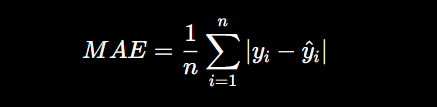

**Where:**
- y = actual value
- ŷ = predicted value


**Intuition**

- MAE answers:

  - On average, how wrong are our predictions?

**Example**

- Actual:

In [ ]:
[100, 120, 140]

[100, 120, 140]

**Predicted:**

In [ ]:
[110, 115, 150]

[110, 115, 150]

**Errors:**

In [ ]:
10
5
10

10

**MAE:**

In [ ]:
print(round((10 + 5 + 10) / 3, 2))

8.33


**Visualization**

In [ ]:
Actual     : 100
Prediction : 110

Error = 10

In [ ]:
Actual     : 120
Prediction : 115

Error = 5

**Python Example**

In [ ]:
from sklearn.metrics import mean_absolute_error

y_true = [100,120,140]
y_pred = [110,115,150]

mae = mean_absolute_error(y_true,y_pred)

print(mae)

8.333333333333334


#**PART 3 — Root Mean Squared Error (RMSE)**

**Definition**

- RMSE measures:

  - Average magnitude of error with extra penalty on large mistakes.


**Formula**

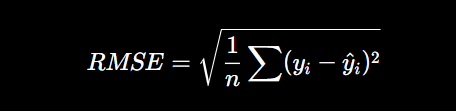

**Intuition**

- Instead of absolute error:

  - RMSE squares errors first.

Large mistakes become much more important.


**Example**

- Errors:


In [ ]:
2
2
20

20

**MAE:**

In [ ]:
8

8

**RMSE:**

In [ ]:
11.66

11.66

Large error impacts RMSE heavily.

**Visualization**

In [ ]:
Error = 2
Squared = 4

In [ ]:
Error = 20
Squared = 400

Huge penalty.

**Python Example**

In [ ]:
from sklearn.metrics import root_mean_squared_error

y_true = [100,120,140]
y_pred = [110,115,150]

rmse = root_mean_squared_error(y_true,y_pred)

print(rmse)

8.660254037844387


#**PART 4 — R² Score**

**Definition**

R² measures:

- How much variance in data is explained by the model.


**Formula**
$$R^2=1−\frac{SS_{res}}
{SS_{tot}}$$
	​

	​
**Where:**

- Residual Sum of Squares:

$$ {SS_{res}} $$

- Total Sum of Squares:

 $$ {SS_{tot}}$$
	​

**Intuition**

- R² compares:

   - Model Performance

      vs

  - Predicting Mean Only



**Baseline Model**

- Suppose every house prediction is:

   - Average House Price

That becomes baseline.

- R² measures improvement over this baseline.


**Interpretation Table**
| R² | Meaning                 |
| -- | ----------------------- |
| 1  | Perfect Prediction      |
| 0  | Same as Mean Prediction |
| <0 | Worse Than Mean         |


**Visualization**

In [ ]:
print("""
R² = 1
Perfect Fit
""")


R² = 1
Perfect Fit



In [ ]:
print("""
R² = 0
No Improvement
""")


R² = 0
No Improvement



In [ ]:
r2 = -1
print(f"R² = {r2}\nDisastrous Model")

R² = -1
Disastrous Model


**Python Example**

In [ ]:
from sklearn.metrics import r2_score

y_true = [100,120,140]
y_pred = [110,115,150]

print(r2_score(y_true,y_pred))

0.71875


#**PART 5 — Adjusted R²**

**Why Adjusted R² Exists**

- Problem:

  - R² almost always increases when new features are added.

Even if features are useless.

**Example**

- Features:

  - Age
  - Salary
  - House Size

- R²:

  - 0.75

- Add:

  - Random Number

R² may increase slightly.

But model didn't improve.

**Adjusted R² Solution**

- Penalizes unnecessary complexity.


**Formula**
- Adjusted $$R^2=1−(1−R^2)\frac{n−1}{n−p−1}$$
	​


**Where:**

- n = samples

- p = predictors

**Intuition**

- Adjusted R² rewards:

**Useful features**

- Penalizes:

  - Useless features

**Example**
| Model   | R²   | Adjusted R² |
| ------- | ---- | ----------- |
| Simple  | 0.75 | 0.74        |
| Complex | 0.78 | 0.71        |


#**PART 6 — Metric Comparison Summary**

**Comparison Table**
| Metric      | Measures           | Sensitive To       |
| ----------- | ------------------ | ------------------ |
| MAE         | Average Error      | Low                |
| RMSE        | Large Errors       | High               |
| R²          | Variance Explained | Complexity Ignored |
| Adjusted R² | Variance + Penalty | Overfitting        |


**Choosing Metrics**


**MAE**

- Use when:

  - Business interpretability matters.

**RMSE**

- Use when:

  - Large mistakes are expensive.

**R²**

- Use when:

  - Understanding explanatory power.

**Adjusted R²**

- Use when:

  - Comparing multiple regression models.

#**PART 7 — Overfitting & Bias–Variance Tradeoff**

**Underfitting**

- Model too simple.

Cannot learn patterns.

**Symptoms**

- Train Error:

  - High

- Test Error:

  - High

**Overfitting**

- Model memorizes training data.

Fails on unseen data.

**Symptoms**

- Train Error:

   - Very Low

- Test Error:

  - High


**Visualization**

In [ ]:
print("""
Underfit

Train Error = High
Test Error  = High
""")


Underfit

Train Error = High
Test Error  = High



In [ ]:
print("""
Good Fit

Train Error = Low
Test Error  = Low
""")


Good Fit

Train Error = Low
Test Error  = Low



In [ ]:
print("""
Overfit

Train Error = Very Low
Test Error  = High
""")


Overfit

Train Error = Very Low
Test Error  = High



**Bias–Variance Tradeoff**

| Bias           | Variance       |
| -------------- | -------------- |
| Underfitting   | Overfitting    |
| Simpler Models | Complex Models |

**Goal:**

- Find balance.

#**PART 8 — Regression Case Study**

**House Price Prediction**

- **Step 1: Build Simple Linear Regression**

In [ ]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

X,y = make_regression(
    n_samples=500,
    n_features=1,
    noise=20,
    random_state=42
)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("MAE :",mean_absolute_error(y_test,pred))
print("RMSE:",root_mean_squared_error(y_test,pred))
print("R2  :",r2_score(y_test,pred))

MAE : 15.396319188087862
RMSE: 19.248749593413216
R2  : 0.9024686518135113


- **Step 2: Create Polynomial Model**

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=10)),
    ("lr", LinearRegression())
])

poly_model.fit(X_train,y_train)

poly_pred = poly_model.predict(X_test)

print("MAE :",mean_absolute_error(y_test,poly_pred))
print("RMSE:",root_mean_squared_error(y_test,poly_pred))
print("R2  :",r2_score(y_test,poly_pred))

MAE : 15.2975742539167
RMSE: 19.533157272045766
R2  : 0.8995652331874713


**Expected Observation**

- **Simple Model**
  - Train Error = Moderate
  - Test Error = Moderate

Generalizes well.

**Polynomial Model**
- Train Error = Very Low
- Test Error = High

Overfits.